In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143
Total spikes in AP: 431640.0


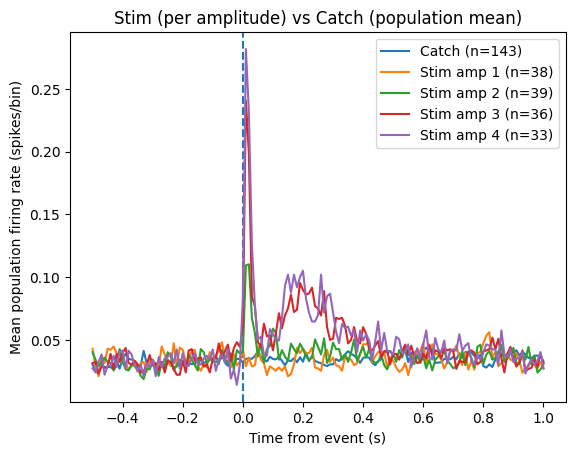

In [13]:
# Creation CD

amps_stim = [1,2,3,4]

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))  # (n_neurons, W)
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)  # (n_trials, n_neurons, W)

# event-triggered mean
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

# stim times par amplitude
stim_sel = tr["whisker_stim_time"].notna() & tr["whisker_stim_amplitude"].isin(amps_stim)

Stim_times_by_amp = {
    a: np.sort(tr.loc[stim_sel & (tr["whisker_stim_amplitude"] == a), "whisker_stim_time"].to_numpy())
    for a in amps_stim
}

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure()
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--")

STM_by_amp = {}
for a in amps_stim:
    STM_by_amp[a], n_st = event_triggered_mean(AP_Bin_Matrx, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins, post_bins)
    plt.plot(time_axis, STM_by_amp[a].mean(axis=0), label=f"Stim amp {a} (n={n_st})")


plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim (per amplitude) vs Catch (population mean)")
plt.legend()
plt.show()

In [22]:
# Creation CD1 : pic principal 0-50ms (amp4)

Pop_Vect_Stim  = STM_by_amp[4][:, 50:55].mean(axis=1)
Pop_Vect_Catch = CATCH_MTRX[:, 50:55].mean(axis=1)

CD = Pop_Vect_Stim - Pop_Vect_Catch
CD = CD / (np.linalg.norm(CD) + 1e-12)

print("CD1 norm:", np.linalg.norm(CD), "shape:", CD.shape)

CD1 norm: 1.0 shape: (30,)


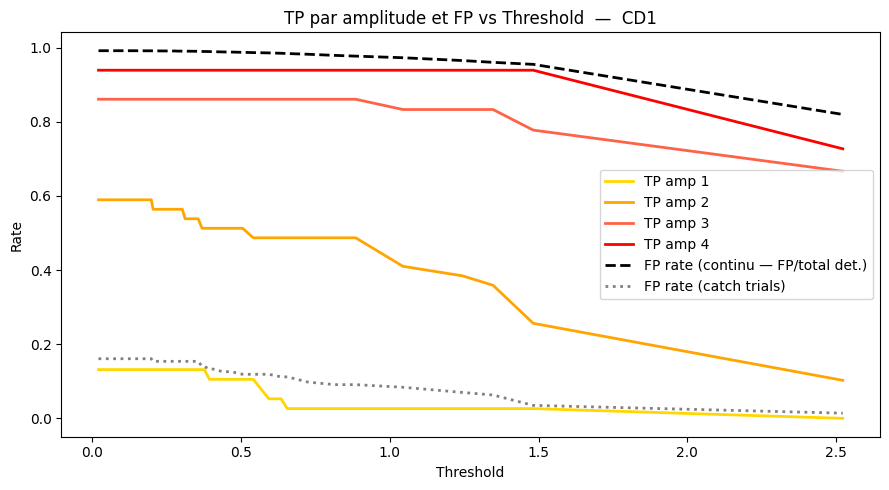

Number of false detection at the best threshold (0.02): 11264 (FP rate: 0.99)


In [ ]:
# Detection sur signal continu via projection CD1

# projection
score = CD @ AP_Bin_Matrx
t_sig = np.arange(len(score)) * Bin_size

# Peak detection
tol_post     = 0.05   # fenetre 50ms apres stim pour compter un TP
refractory_s = 0.2    # periode refractaire entre deux detections

t_start = float(tr["start_time"].min())
t_end   = float(tr["stop_time"].max())

def detect_peaks(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask = (t >= t_start) & (t <= t_end) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refractory_s / Bin_size))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

# threshold
in_range = (t_sig >= t_start) & (t_sig <= t_end)
ths      = np.percentile(score[in_range], np.linspace(50, 99.9, 80))

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_stim]))
n_catch_trials = len(Catch_times)

tp_curves        = {a: [] for a in amps_stim}
fp_cont_curve    = []   # FP / total detections (signal continu)
fp_catch_curve   = []   # detections dans fenetres catch / n_catch_trials

for thr in ths:
    det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    # FP continu : detections hors de toute fenetre stim / total detections
    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_cont_curve.append(np.sum(~in_win_any) / n_det)

    # keep number of false detections at best threshold for later
    if len(fp_cont_curve) == 1:  # first threshold (lowest)
        in_win_any_at_best = in_win_any.copy()
        n_det_at_best = n_det

    # FP catch : combien de catch trials ont une detection dans leur fenetre
    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post))
        for st in Catch_times
    )
    fp_catch_curve.append(hits_catch / max(n_catch_trials, 1))

    # TP par amplitude
    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_curves[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_curves      = {a: np.array(tp_curves[a]) for a in amps_stim}
fp_cont_curve  = np.array(fp_cont_curve)
fp_catch_curve = np.array(fp_catch_curve)

# plot
colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths, tp_curves[a], color=colors_amp[a], lw=2, label=f"TP amp {a}")
plt.plot(ths, fp_cont_curve,  color="black",  lw=2, linestyle="--", label="FP rate (continu — FP/total det.)")
plt.plot(ths, fp_catch_curve, color="gray",   lw=2, linestyle=":",  label="FP rate (catch trials)")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TP par amplitude et FP vs Threshold  —  CD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Number of false detection at the best threshold ({ths[0]:.2f}): {n_det_at_best} (FP rate: {np.sum(~in_win_any_at_best) / n_det_at_best:.2f})")

Threshold : 0.158  |  FP : 10935
  TP amp1 : 5
  TP amp2 : 23
  TP amp3 : 31
  TP amp4 : 31
Cosine sim amp1 : 0.431 ± 0.131
Cosine sim amp2 : 0.614 ± 0.163
Cosine sim amp3 : 0.792 ± 0.101
Cosine sim amp4 : 0.830 ± 0.056
Cosine sim FP   : 0.432 ± 0.147


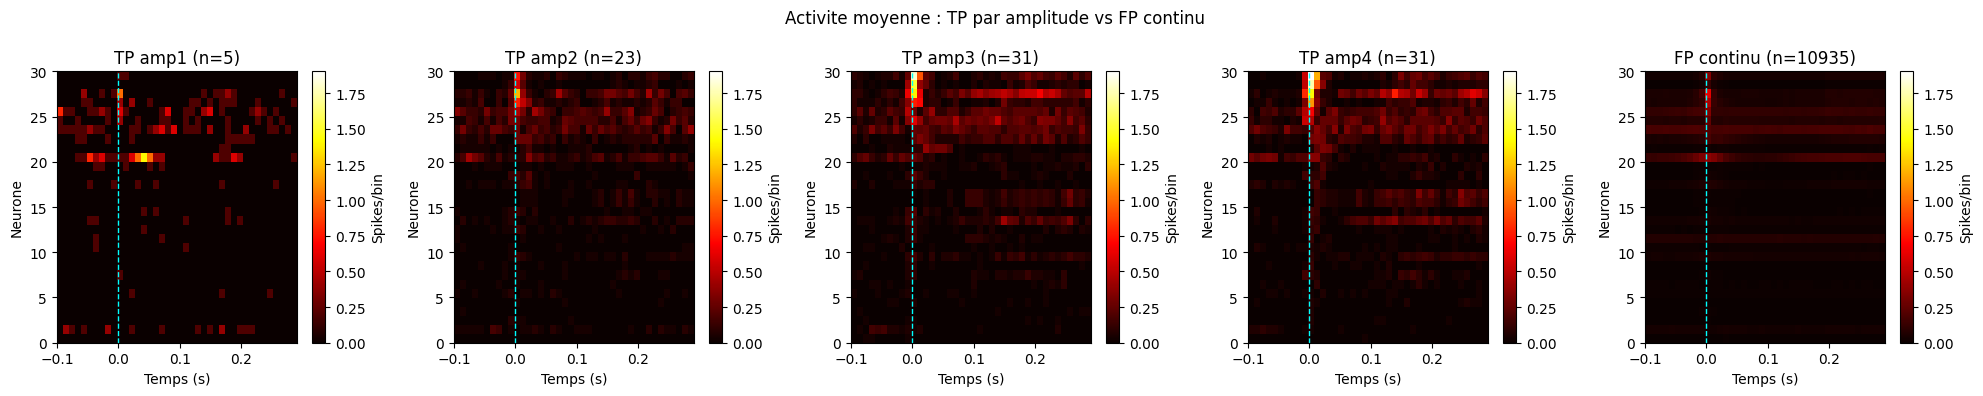

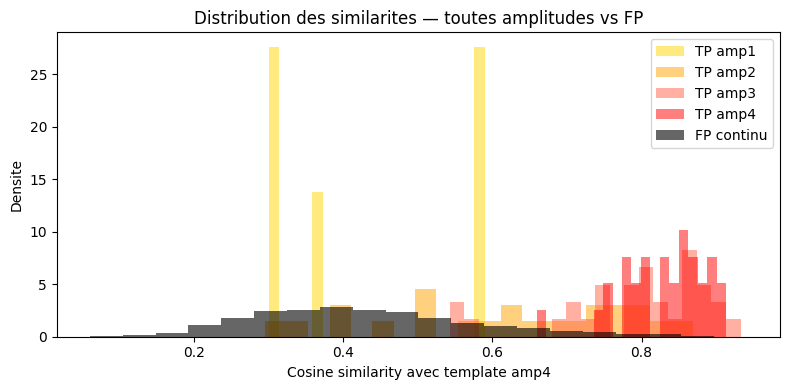

In [34]:
# Similarite entre FP continu et vraies reponses (toutes amplitudes)
# On montre que les FP ne sont pas du bruit mais des evenements spontanes qui ressemblent a une stim

# Template = reponse stim amp4 normalisee
template = Pop_Vect_Stim / (np.linalg.norm(Pop_Vect_Stim) + 1e-12)

# Seuil median pour avoir assez de FP
thr_fixed = np.median(ths)
det_t = detect_peaks(score, t_sig, thr_fixed, refractory_s, Bin_size, t_start, t_end)

# FP : hors de toute fenetre stim
in_win_any = np.zeros(len(det_t), dtype=bool)
for st in all_stim_times:
    in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
fp_times = det_t[~in_win_any]

# TP par amplitude
tp_times_by_amp = {}
for a in amps_stim:
    in_win = np.zeros(len(det_t), dtype=bool)
    for st in Stim_times_by_amp[a]:
        in_win |= (det_t >= st) & (det_t <= st + tol_post)
    tp_times_by_amp[a] = det_t[in_win]

print(f"Threshold : {thr_fixed:.3f}  |  FP : {len(fp_times)}")
for a in amps_stim:
    print(f"  TP amp{a} : {len(tp_times_by_amp[a])}")

# Extraction des fenetres
pre, post = 10, 30
t_win = (np.arange(pre + post) - pre) * Bin_size

def extract_windows(times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > AP_Bin_Matrx.shape[1]:
            continue
        segs.append(AP_Bin_Matrx[:, pt - pre:pt + post])
    return np.array(segs) if segs else None

def pop_vecs_at_peak(segs, pre, W=5):
    vecs = segs[:, :, pre:pre+W].mean(axis=2)
    return vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)

segs_fp = extract_windows(fp_times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
fp_vecs = pop_vecs_at_peak(segs_fp, pre)
cos_fp  = fp_vecs @ template

segs_by_amp = {}
cos_by_amp  = {}
for a in amps_stim:
    segs_by_amp[a] = extract_windows(tp_times_by_amp[a], AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
    if segs_by_amp[a] is not None:
        vecs = pop_vecs_at_peak(segs_by_amp[a], pre)
        cos_by_amp[a] = vecs @ template
        print(f"Cosine sim amp{a} : {cos_by_amp[a].mean():.3f} ± {cos_by_amp[a].std():.3f}")
print(f"Cosine sim FP   : {cos_fp.mean():.3f} ± {cos_fp.std():.3f}")

# Heatmaps : une par amplitude + FP
n_cols = len(amps_stim) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

# Trier les neurones par reponse amp4
mean_tp4 = segs_by_amp[4].mean(axis=0)
sort_idx = np.argsort(mean_tp4[:, pre:pre+5].mean(axis=1))[::-1]
mean_fp  = segs_fp.mean(axis=0)
lim = max(segs_by_amp[a].mean(axis=0).max() for a in amps_stim if segs_by_amp[a] is not None)
lim = max(lim, mean_fp.max())

for i, a in enumerate(amps_stim):
    if segs_by_amp[a] is None:
        continue
    data = segs_by_amp[a].mean(axis=0)[sort_idx]
    im = axes[i].imshow(data, aspect="auto", cmap="hot", vmin=0, vmax=lim,
                        extent=[t_win[0], t_win[-1], 0, data.shape[0]])
    axes[i].axvline(0, color="cyan", lw=1, linestyle="--")
    axes[i].set_title(f"TP amp{a} (n={len(tp_times_by_amp[a])})")
    axes[i].set_xlabel("Temps (s)")
    axes[i].set_ylabel("Neurone")
    plt.colorbar(im, ax=axes[i], label="Spikes/bin")

data_fp = mean_fp[sort_idx]
im = axes[-1].imshow(data_fp, aspect="auto", cmap="hot", vmin=0, vmax=lim,
                     extent=[t_win[0], t_win[-1], 0, data_fp.shape[0]])
axes[-1].axvline(0, color="cyan", lw=1, linestyle="--")
axes[-1].set_title(f"FP continu (n={len(fp_times)})")
axes[-1].set_xlabel("Temps (s)")
axes[-1].set_ylabel("Neurone")
plt.colorbar(im, ax=axes[-1], label="Spikes/bin")

plt.suptitle("Activite moyenne : TP par amplitude vs FP continu")
plt.tight_layout()
plt.show()

# Distribution cosine similarities
plt.figure(figsize=(8, 4))
for a in amps_stim:
    if a in cos_by_amp:
        plt.hist(cos_by_amp[a], bins=20, alpha=0.5, color=colors_amp[a], label=f"TP amp{a}", density=True)
plt.hist(cos_fp, bins=20, alpha=0.6, color="black", label=f"FP continu", density=True)
plt.xlabel("Cosine similarity avec template amp4")
plt.ylabel("Densite")
plt.title("Distribution des similarites — toutes amplitudes vs FP")
plt.legend()
plt.tight_layout()
plt.show()


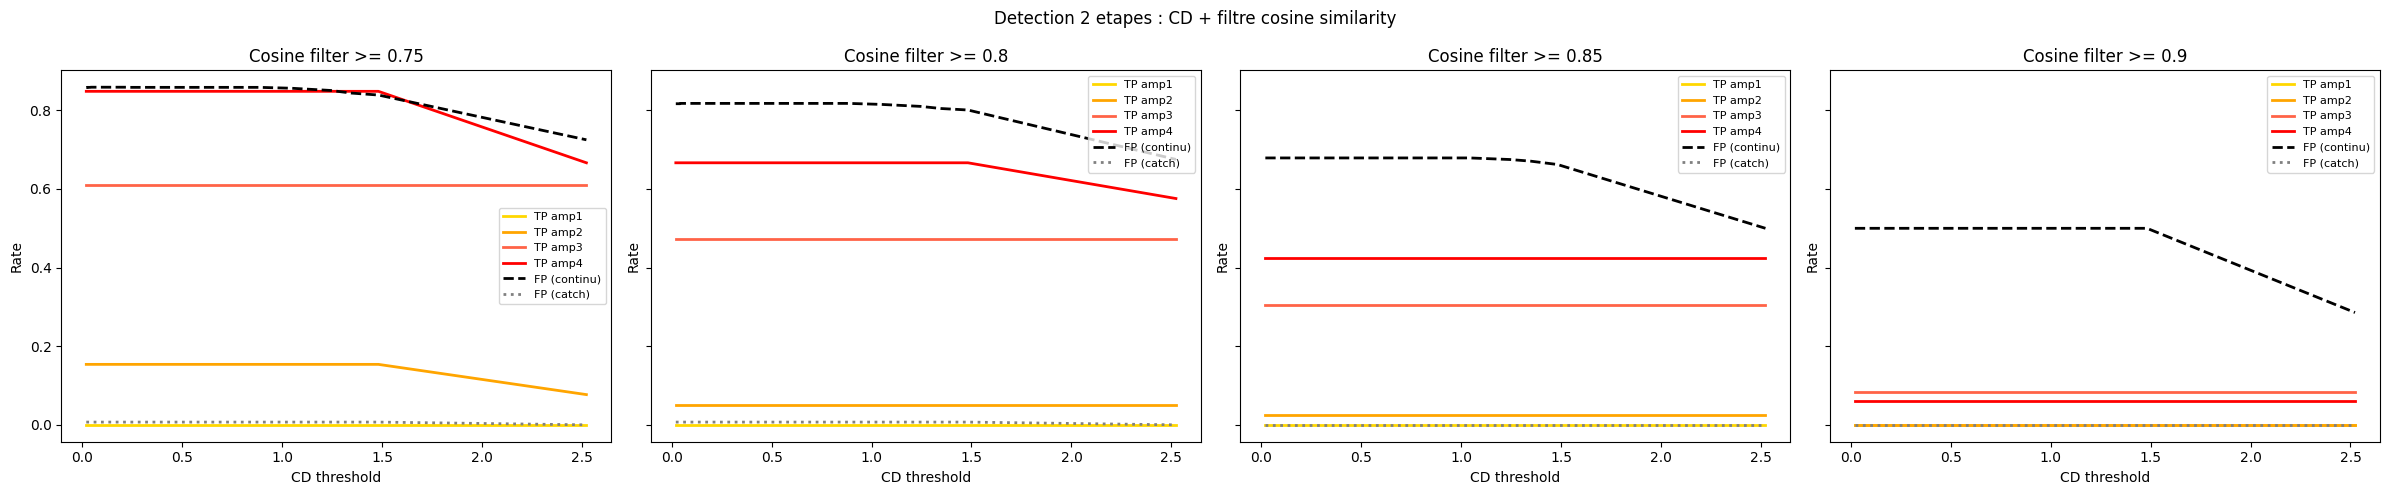

In [37]:
# second detection with cosine similarity
# Etape 1 : detecter les pics sur le score CD
# Etape 2 : pour chaque detection, calculer la cosine similarity de la fenetre de population avec le template
# Garder uniquement les detections au-dessus d'un seuil cosine

W_cos = 5  # fenetre 50ms pour calculer le vecteur population

def cosine_sim_at_times(times, AP_Bin_Matrx, AP_Bin_Resolution, template, W):
    sims = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt + W > AP_Bin_Matrx.shape[1]:
            sims.append(0.0)
            continue
        vec = AP_Bin_Matrx[:, pt:pt + W].mean(axis=1).astype(np.float32)
        vec = vec / (np.linalg.norm(vec) + 1e-12)
        sims.append(float(vec @ template))
    return np.array(sims)

# Sweep CD threshold avec filtre cosine fixe
cos_thresholds = [0.75, 0.8, 0.85, 0.9]
colors_cos = {0.75: "magenta", 0.8: "yellow", 0.85: "brown", 0.9: "pink"}

fig, axes = plt.subplots(1, len(cos_thresholds), figsize=(6 * len(cos_thresholds), 5), sharey=True)

for ax, cos_thr in zip(axes, cos_thresholds):
    tp_c  = {a: [] for a in amps_stim}
    fp_co = []
    fp_ca = []

    for thr in ths:
        det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)

        # Filtre cosine
        if len(det_t) > 0:
            sims  = cosine_sim_at_times(det_t, AP_Bin_Matrx, AP_Bin_Resolution, template, W_cos)
            det_t = det_t[sims >= cos_thr]

        n_det = max(len(det_t), 1)

        in_win_any = np.zeros(len(det_t), dtype=bool)
        for st in all_stim_times:
            in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
        fp_co.append(np.sum(~in_win_any) / n_det)

        hits_catch = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Catch_times
        )
        fp_ca.append(hits_catch / max(n_catch_trials, 1))

        for a in amps_stim:
            hits = sum(
                np.any((det_t >= st) & (det_t <= st + tol_post))
                for st in Stim_times_by_amp[a]
            )
            tp_c[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

    for a in amps_stim:
        ax.plot(ths, tp_c[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
    ax.plot(ths, fp_co, color="black", lw=2, linestyle="--", label="FP (continu)")
    ax.plot(ths, fp_ca, color="gray",  lw=2, linestyle=":",  label="FP (catch)")
    ax.set_xlabel("CD threshold")
    ax.set_ylabel("Rate")
    ax.set_title(f"Cosine filter >= {cos_thr}")
    ax.legend(fontsize=8)

plt.suptitle("Detection 2 etapes : CD + filtre cosine similarity")
plt.tight_layout()
plt.show()
